# Predicting Credit Default Risk

## 1. Project Overview & Executive Summary
Credit risk assessment is a critical function for financial institutions. The ability to accurately predict whether a borrower will default on a loan directly impacts profitability and lending strategy. 

**Objective:** The primary goal of this project is to build a robust machine learning classification model to predict credit default risk. By analyzing historical loan applications, borrower characteristics, and credit inquiry data, this model will identify high-risk applicants and provide actionable insights for credit-risk decision-making.

**The Prediction Target:** We define default as a binary outcome:
* `target_default = 1` (Applicant defaulted / "Charged Off")
* `target_default = 0` (Applicant did not default/ "Fully Paid")

**Datasets Used:**
1. **Applications Data:** Contains borrower profiles, loan details, and final outcomes.
2. **Inquiries Data:** Contains supplementary credit inquiry information.

---
## 2. Initial Data Loading & Inspection
Before applying any transformations, we will load the raw datasets and perform an initial profile to understand their structure, data types, and identify any immediate data quality issues (missing values, incorrect formatting, etc.).

In [578]:
# importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [579]:
# loading the datasets into a pandas dataframe

cr_applications_df=pd.read_csv('datasets/creditrisk_applications_final.csv')
cr_inquiries_df=pd.read_csv('datasets/creditrisk_inquiries_final.csv')

In [580]:
print("="*50)
print("APPLICATIONS DATA: FIRST 5 ROWS")
print("="*50)
cr_applications_df.head()

APPLICATIONS DATA: FIRST 5 ROWS


,application_id,requested_amount_usd,repayment_term_text,interest_rate_text,monthly_installment_usd,last_payment_amount_usd,risk_grade_band,risk_grade_detail,employment_tenure_text,housing_status,...,origination_month,outcome_status,loan_purpose,region_code,debt_to_income_ratio,credit_score_low,credit_score_high,open_credit_lines,public_records_count,revolving_utilization_text
0,41080563,18000.0,60 months,13.33,412.61,15325.62,C,C3,3 years,OWN,...,Feb-2015,Fully Paid,debt_consolidation,AZ,6.78,670.0,674.0,7.0,0.0,89.5
1,76295652,1000.0,36 months,11.99,33.21,842.45,C,C1,1 year,RENT,...,Apr-2016,Fully Paid,home_improvement,FL,11.54,690.0,694.0,3.0,1.0,13.3
2,60586596,21275.0,36 months,10.99,696.42,7380.80,B,B4,5 years,MORTGAGE,...,Sep-2015,Fully Paid,debt_consolidation,PA,23.08,680.0,684.0,13.0,0.0,75.7
3,59310389,35000.0,60 months,16.99,869.66,32305.48,D,D3,10+ years,MORTGAGE,...,Sep-2015,Fully Paid,credit_card,SC,16.3,710.0,714.0,10.0,0.0,76.5
4,44516103,17000.0,60 months,17.57,427.73,427.73,D,D4,8 years,RENT,...,Apr-2015,Charged Off,credit_card,CA,31.27,680.0,684.0,8.0,0.0,62.5


In [581]:
print("="*50)
print("INQUIRIES DATA: FIRST 5 ROWS")
print("="*50)
cr_applications_df.head()
cr_inquiries_df.head()

INQUIRIES DATA: FIRST 5 ROWS


,requested_amount_usd,application_date,request_title,screening_score,debt_to_income_text,region_code,employment_tenure_text,policy_code
0,1000.0,2007-05-26,Wedding Covered but No Honeymoon,693.0,10%,NM,4 years,0.0
1,1000.0,2007-05-26,Consolidating Debt,703.0,10%,MA,< 1 year,0.0
2,11000.0,2007-05-27,Want to consolidate my debt,715.0,10%,MD,1 year,0.0
3,6000.0,2007-05-27,waksman,698.0,38.64%,MA,< 1 year,0.0
4,1500.0,2007-05-27,mdrigo,509.0,9.43%,MD,< 1 year,0.0


In [582]:
# Exploring the data shapes

print("="*50)
print("DATASET SHAPES")
print("="*50)
print(f"Applications Data: {cr_applications_df.shape[0]} rows, {cr_applications_df.shape[1]} columns")
print(f"Inquiries Data:    {cr_inquiries_df.shape[0]} rows, {cr_inquiries_df.shape[1]} columns\n")

DATASET SHAPES
Applications Data: 85000 rows, 22 columns
Inquiries Data:    45000 rows, 8 columns



In [583]:
print("="*50)
print("APPLICATIONS DATA: INFO & DATA TYPES")
print("="*50)
cr_applications_df.info()
print("\n")

APPLICATIONS DATA: INFO & DATA TYPES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85000 entries, 0 to 84999
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   application_id              85000 non-null  int64  
 1   requested_amount_usd        85000 non-null  float64
 2   repayment_term_text         85000 non-null  object 
 3   interest_rate_text          85000 non-null  float64
 4   monthly_installment_usd     85000 non-null  float64
 5   last_payment_amount_usd     85000 non-null  float64
 6   risk_grade_band             85000 non-null  object 
 7   risk_grade_detail           85000 non-null  object 
 8   employment_tenure_text      76324 non-null  object 
 9   housing_status              85000 non-null  object 
 10  annual_income_usd           84320 non-null  float64
 11  income_verification_status  85000 non-null  object 
 12  origination_month           85000 non-null  object 

In [584]:
print("="*50)
print("INQUIRIES DATA: INFO & DATA TYPES")
print("="*50)
cr_inquiries_df.info()
print("\n")

INQUIRIES DATA: INFO & DATA TYPES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   requested_amount_usd    45000 non-null  float64
 1   application_date        45000 non-null  object 
 2   request_title           44991 non-null  object 
 3   screening_score         40476 non-null  float64
 4   debt_to_income_text     45000 non-null  object 
 5   region_code             44979 non-null  object 
 6   employment_tenure_text  44998 non-null  object 
 7   policy_code             45000 non-null  float64
dtypes: float64(3), object(5)
memory usage: 2.7+ MB




In [585]:
# Missing Values Check
print("="*50)
print("MISSING VALUES SUMMARY")
print("="*50)
print("Applications Data (Missing > 0):")
app_missing = cr_applications_df.isnull().sum()
print(app_missing[app_missing > 0].sort_values(ascending=False))


print("\nInquiries Data (Missing > 0):")
inq_missing = cr_inquiries_df.isnull().sum()
print(inq_missing[inq_missing > 0].sort_values(ascending=False))
print("\n")

MISSING VALUES SUMMARY
Applications Data (Missing > 0):
employment_tenure_text        8676
revolving_utilization_text     892
debt_to_income_ratio           709
annual_income_usd              680
dtype: int64

Inquiries Data (Missing > 0):
screening_score           4524
region_code                 21
request_title                9
employment_tenure_text       2
dtype: int64




In [586]:
# duplicated row Check
print("="*50)
print("DUPLICATED ROWS SUMMARY")
print("="*50)
print("Applications Data (Duplicated > 0):")
app_duplicates = cr_applications_df.duplicated(keep='first').sum()
print(f"Number of duplicated rows in Applications Data: {app_duplicates}")

print("\nInquiries Data (Duplicated > 0):")
inq_duplicates = cr_inquiries_df.duplicated(keep='first').sum()
print(f"Number of duplicated rows in Inquiries Data: {inq_duplicates}")
print("\n")


DUPLICATED ROWS SUMMARY
Applications Data (Duplicated > 0):
Number of duplicated rows in Applications Data: 0

Inquiries Data (Duplicated > 0):
Number of duplicated rows in Inquiries Data: 15




In [587]:
# Statistical Summary
print("="*50)
print("APPLICATIONS DATA: STATISTICAL SUMMARY (NUMERICAL)")
print("="*50)
display(cr_applications_df.describe())

APPLICATIONS DATA: STATISTICAL SUMMARY (NUMERICAL)


,application_id,requested_amount_usd,interest_rate_text,monthly_installment_usd,last_payment_amount_usd,annual_income_usd,credit_score_low,credit_score_high,open_credit_lines,public_records_count,revolving_utilization_text
count,8.500000e+04,85000.000000,85000.000000,85000.000000,85000.000000,8.432000e+04,85000.000000,85000.000000,85000.000000,85000.000000,84108.000000
mean,6.633685e+07,14950.852647,13.600630,446.071413,3604.090989,7.434189e+04,692.034412,696.034482,11.920871,0.248718,52.342891
std,2.482399e+07,8735.147461,4.886372,258.523612,6222.901104,7.732271e+04,29.787475,29.787839,5.670095,0.656437,24.293508
min,3.476740e+05,1000.000000,5.310000,30.120000,0.000000,0.000000e+00,660.000000,664.000000,1.000000,0.000000,0.000000
25%,4.881616e+07,8000.000000,9.990000,259.955000,308.220000,4.500000e+04,670.000000,674.000000,8.000000,0.000000,34.200000
50%,6.059760e+07,13050.000000,13.180000,382.870000,598.895000,6.300000e+04,685.000000,689.000000,11.000000,0.000000,52.800000
75%,7.635120e+07,20000.000000,16.550000,587.690000,4130.377500,9.000000e+04,705.000000,709.000000,15.000000,0.000000,70.900000
max,1.411120e+08,40000.000000,30.990000,1587.230000,40551.270000,8.900060e+06,845.000000,850.000000,70.000000,49.000000,136.400000


In [588]:
# Statistical Summary
print("="*50)
print("INQUIRIES DATA: STATISTICAL SUMMARY (NUMERICAL)")
print("="*50)
display(cr_inquiries_df.describe())

INQUIRIES DATA: STATISTICAL SUMMARY (NUMERICAL)


,requested_amount_usd,screening_score,policy_code
count,45000.000000,40476.000000,45000.0
mean,9039.969925,574.065743,0.0
std,6902.052667,154.736712,0.0
min,500.000000,0.000000,0.0
25%,3500.000000,513.000000,0.0
50%,7000.000000,609.000000,0.0
75%,14000.000000,670.000000,0.0
max,40000.000000,828.000000,0.0


## 3. Comprehensive Data Cleaning & Transformation

To ensure a robust foundation for modeling, the dataset requires structural cleaning, deduplication, and handling of missing values. We apply transformations to independent copies of the raw data (`cr_app_clean_df` and `cr_inq_clean_df`).

In [589]:
# Create Working Copies for cleaning and Transformation.
cr_app_clean_df = cr_applications_df.copy()
cr_inq_clean_df = cr_inquiries_df.copy()

**Application Data Cleaning**

In [590]:
# Deduplication
# Only the Inquiries dataset has duplicates, so we will deduplicate the dataset.

cr_inq_clean_df.drop_duplicates(keep='first', inplace=True)

# Target Variable Encoding.
# Generated here to allow for bivariate analysis during EDA
cr_app_clean_df['target_default'] = np.where(cr_app_clean_df['outcome_status'] == 'Charged Off', 1, 0)

# String Cleaning & Formatting - Loan Purpose happens to have leading/trailing spaces, so we will clean it.
cr_app_clean_df['loan_purpose'] = cr_app_clean_df['loan_purpose'].astype(str).str.strip()

# Date Formatting
cr_app_clean_df['origination_month'] = pd.to_datetime(cr_app_clean_df['origination_month'], format='%b-%Y', errors='coerce')

# Text-to-Numeric Parsing 
# Applications Data
cr_app_clean_df['repayment_term_months'] = cr_app_clean_df['repayment_term_text'].astype(str).str.replace(' months', '', regex=False).str.strip().astype(float) # remome months text and convert to float 
cr_app_clean_df['interest_rate'] = cr_app_clean_df['interest_rate_text'].astype(str).str.strip().astype(float) # remove leading/trailing spaces and convert to float
cr_app_clean_df['revolving_utilization'] = cr_app_clean_df['revolving_utilization_text'].astype(str).str.replace('%', '', regex=False).str.strip().astype(float) # remove leading/trailing spaces and convert to float
cr_app_clean_df['employment_tenure_years'] = cr_app_clean_df['employment_tenure_text'].astype(str).str.extract(r'(\d+)').astype(float)

cr_app_clean_df['debt_to_income_ratio'] = (
    pd.to_numeric(
        cr_app_clean_df['debt_to_income_ratio'].astype(str).str.strip(),
        errors='coerce'
    ) # Convert to numeric, coercing errors to NaN
)



In [591]:
# Standardize housing status casing
cr_app_clean_df['housing_status'] = (cr_app_clean_df['housing_status'].astype(str).str.strip().str.title())

cr_app_clean_df['region_code'] = (cr_app_clean_df['region_code'].astype(str).str.strip().str.upper()) # Standardize region code casing


In [592]:
# Missing Value Imputation

# Numerical: Median Imputation
app_num_cols = ['employment_tenure_years', 'revolving_utilization', 'debt_to_income_ratio', 'annual_income_usd']
for col in app_num_cols:
    cr_app_clean_df[col] = cr_app_clean_df[col].fillna(cr_app_clean_df[col].median())

In [593]:
# Drop Redundant Raw Text Columns
cols_to_drop_apps = ['repayment_term_text', 'interest_rate_text', 'revolving_utilization_text', 'employment_tenure_text']
cr_app_clean_df.drop(columns=[col for col in cols_to_drop_apps if col in cr_app_clean_df.columns], inplace=True)


**Inquiries Data Cleaning**


In [594]:
# Inquiries Data
cr_inq_clean_df['employment_tenure_years'] = cr_inq_clean_df['employment_tenure_text'].astype(str).str.extract(r'(\d+)').astype(float)
cr_inq_clean_df['debt_to_income'] = cr_inq_clean_df['debt_to_income_text'].astype(str).str.replace('%', '', regex=False).str.strip().astype(float)

# Date Formatting
cr_inq_clean_df['application_date'] = pd.to_datetime(cr_inq_clean_df['application_date'], errors='coerce')

In [595]:
# Missing Value Imputation

# Numerical: Median Imputation
inq_num_cols = ['screening_score', 'employment_tenure_years', 'debt_to_income']
for col in inq_num_cols:
    cr_inq_clean_df[col] = cr_inq_clean_df[col].fillna(cr_inq_clean_df[col].median())

# Categorical: Mode and Unknown Imputation
cr_inq_clean_df['region_code'] = cr_inq_clean_df['region_code'].fillna(cr_inq_clean_df['region_code'].mode()[0])
cr_inq_clean_df['request_title'] = cr_inq_clean_df['request_title'].fillna('Unknown')

In [596]:
# Drop Redundant Raw Text Columns

cr_inq_clean_df.drop(columns=['debt_to_income_text', 'employment_tenure_text'], inplace=True, errors='ignore')

In [597]:
# Final Quality Check
print("="*50)
print("CLEANING COMPLETE: MISSING VALUES REMAINING")
print("="*50)
print(f"Applications Dataset: {cr_app_clean_df.isnull().sum().sum()} missing values")
print(f"Inquiries Dataset:    {cr_inq_clean_df.isnull().sum().sum()} missing values")

print("\n" + "="*50)
print("NEW DATA TYPES (APPLICATIONS SNAPSHOT)")
print("="*50)
print(cr_app_clean_df[['origination_month', 'debt_to_income_ratio', 'repayment_term_months', 'target_default']].dtypes)


CLEANING COMPLETE: MISSING VALUES REMAINING
Applications Dataset: 0 missing values
Inquiries Dataset:    0 missing values

NEW DATA TYPES (APPLICATIONS SNAPSHOT)
origination_month        datetime64[ns]
debt_to_income_ratio            float64
repayment_term_months           float64
target_default                    int64
dtype: object


**Transformation & Integrity Measures:**

1. **Target Variable Optimization:** The binary classification target `target_default` is encoded immediately from `outcome_status` to facilitate bivariate tracking and segmentation during Exploratory Data Analysis (EDA).

2. **Text-to-Numeric Conversion**: Raw string fields (like " 36 months", "13.33", and "89.5%") are parsed into standard floating-point numbers.

3. **Robust Text Parsing**: We use pd.to_numeric(errors='coerce') on financial metrics. This safely converts format anomalies into missing values (NaN) instead of crashing the script.

4. **Data-Driven Missing Value Imputation:** - **Numerical Scale Fields:** Missing values and coerced fields are safely resolved via median imputation, ensuring that localized missingness does not distort overall data distribution shapes or central tendencies.
   - **Categorical Columns:** Missing values in critical categories are handled using the statistical mode or flagged with an explicit `"Unknown"` marker to preserve structural group history.

5. **Categorical Columns**: Missing values are filled using the most frequent group (mode) or labeled as "Unknown".

6. **Outlier Preservation**: Extreme values in the debt-to-income ratio are intentionally left uncapped. In credit risk, a massive debt load often points to high real-world risk rather than a system glitch; keeping them preserves vital patterns.

6. **String & Date Standardization:** Whitespace is systematically stripped from categorical arrays like `loan_purpose`, and chronological data fields are shifted to datetime formats.

**Summary of Transformations**

The cleaning process resulted in:

- removal of duplicate inquiry records
- creation of a binary default target variable
- standardized text categories
- conversion of text-based numerical variables into numeric format
- conversion of date fields into datetime format
- treatment of missing values
- removal of redundant columns

The resulting datasets are now structured and suitable for exploratory data analysis

## 4. Exploratory Data Analysis (EDA) & Visualization

Having established a clean, unified data structure, our objective in this phase is to develop a deep intuition regarding the fundamental drivers of credit default risk. We move beyond raw rows to uncover behavioral, financial, and structural patterns.

**Analytical Strategy:**
1. **Statistical Profiling:** Compute baseline summary statistics to understand the scale, central tendency, and dispersion of borrower financials.
2. **Target Distribution:** Establish the foundational baseline default rate.
3. **Categorical Risk Drivers:** Evaluate default variance across assigned risk grades and stated loan purposes.
4. **Continuous Risk Drivers:** Examine how continuous financial pressures (Interest Rates, Debt-to-Income) shift between performing and non-performing loans.
5. **Correlation & Multicollinearity:** Map the interconnectedness of numerical features to guide eventual feature selection.

In [598]:
print("=" * 60)
print("SUMMARY STATISTICS: KEY FINANCIAL FEATURES")
print("=" * 60)
display(cr_app_clean_df[['requested_amount_usd', 'annual_income_usd', 'debt_to_income_ratio', 'interest_rate']].describe().round(2))
print("\n")

SUMMARY STATISTICS: KEY FINANCIAL FEATURES


,requested_amount_usd,annual_income_usd,debt_to_income_ratio,interest_rate
count,85000.00,85000.00,85000.00,85000.00
mean,14950.85,74251.15,19.67,13.60
std,8735.15,77019.42,13.09,4.89
min,1000.00,0.00,0.00,5.31
25%,8000.00,45000.00,12.87,9.99
50%,13050.00,63000.00,18.99,13.18
75%,20000.00,89665.00,25.81,16.55
max,40000.00,8900060.00,999.00,30.99


In [599]:
# Visual Configuration
sns.set_theme(style="white") # Clean white background
plt.rcParams['font.size'] = 11
color_base = '#95a5a6'  # Neutral Grey
color_safe = '#2980b9'  # Trust Blue
color_risk = '#c0392b'  # Alert Red

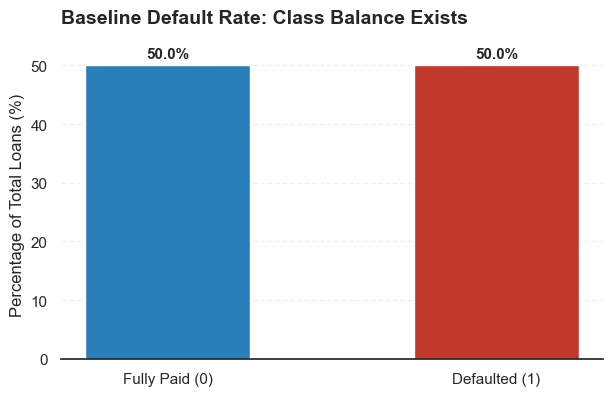

In [625]:
# Figure 1: Baseline Target Distribution
fig, ax = plt.subplots(figsize=(7, 4))
target_counts = cr_app_clean_df['target_default'].value_counts(normalize=True) * 100
bars = ax.bar(['Fully Paid (0)', 'Defaulted (1)'], target_counts, color=[color_safe, color_risk], width=0.5)

ax.set_title('Baseline Default Rate: Class Balance Exists', loc='left', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Percentage of Total Loans (%)')
sns.despine(left=True, bottom=False) # Remove borders
ax.yaxis.grid(True, linestyle='--', alpha=0.3) # Light gridlines

# Add percentage labels
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')
plt.show()

In [601]:
# Counts
target_counts = cr_app_clean_df['target_default'].value_counts()

# Percentages
target_pct = cr_app_clean_df['target_default'].value_counts(normalize=True) * 100

# Build DataFrame
fig1_df = pd.DataFrame({'target_default': target_counts.index, 'count': target_counts.values, 'percentage': target_pct.values})

fig1_df['target_label'] = fig1_df['target_default'].map({0: 'Fully Paid', 1: 'Defaulted'})

# Reorder columns
fig1_df = fig1_df[['target_default', 'target_label', 'count', 'percentage']]

fig1_df

,target_default,target_label,count,percentage
0,0,Fully Paid,42500,50.0
1,1,Defaulted,42500,50.0


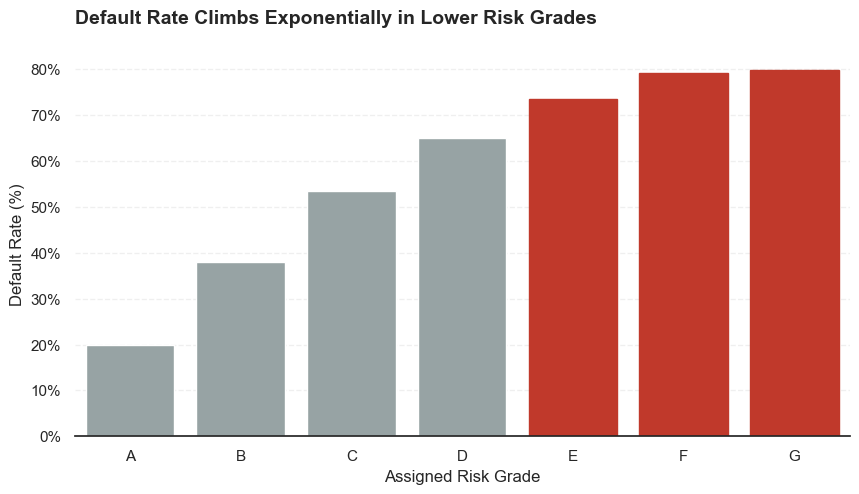

In [602]:
# Figure 2: Risk Grade as a Predictor
fig, ax = plt.subplots(figsize=(10, 5))
risk_data = cr_app_clean_df.groupby('risk_grade_band')['target_default'].mean() * 100
risk_order = sorted(cr_app_clean_df['risk_grade_band'].dropna().unique())

sns.barplot(data=cr_app_clean_df, x='risk_grade_band', y='target_default', 
            order=risk_order, errorbar=None, color=color_base, ax=ax)

# Highlight highest risk grades in red
for i, bar in enumerate(ax.patches):
    if i >= 4:  # Highlighting grades E, F, G as higher risk
        bar.set_color(color_risk)

ax.set_title('Default Rate Climbs Exponentially in Lower Risk Grades', loc='left', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Default Rate (%)')
ax.set_xlabel('Assigned Risk Grade')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y))) 
sns.despine(left=True)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
plt.show()

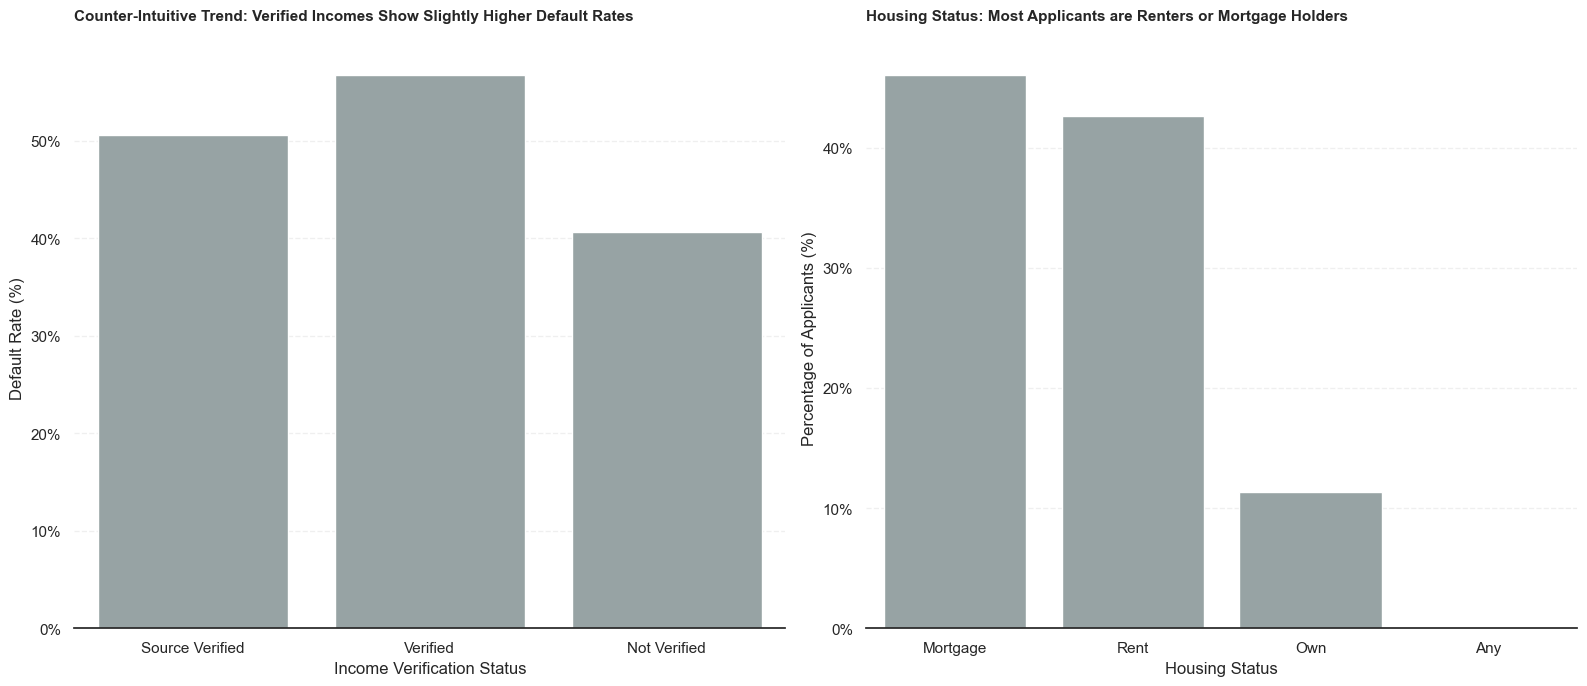

In [603]:
# Figure 3
# Create a single figure with a 1x2 subplot layout
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# -----------------------------------------------------------------------------
# Subplot 1: Income Verification Status
# -----------------------------------------------------------------------------
verif_order = cr_app_clean_df['income_verification_status'].value_counts().index
sns.barplot(
    data=cr_app_clean_df, 
    x='income_verification_status', 
    y='target_default', 
    order=verif_order, 
    errorbar=None, 
    color=color_base, 
    ax=axes[0]
)

axes[0].set_title('Counter-Intuitive Trend: Verified Incomes Show Slightly Higher Default Rates', loc='left', fontsize=11, fontweight='bold', pad=20)
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_xlabel('Income Verification Status')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
axes[0].yaxis.grid(True, linestyle='--', alpha=0.3)
sns.despine(left=True, ax=axes[0])

# -----------------------------------------------------------------------------
# Subplot 2: Housing Status Distribution
# -----------------------------------------------------------------------------
housing_counts = cr_app_clean_df['housing_status'].value_counts(normalize=True) * 100
sns.barplot(
    x=housing_counts.index, 
    y=housing_counts.values, 
    color=color_base, 
    ax=axes[1]
)

axes[1].set_title('Housing Status: Most Applicants are Renters or Mortgage Holders', loc='left', fontsize=11, fontweight='bold', pad=20)
axes[1].set_ylabel('Percentage of Applicants (%)')
axes[1].set_xlabel('Housing Status')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0f}%'.format(y)))
axes[1].yaxis.grid(True, linestyle='--', alpha=0.3)
sns.despine(left=True, ax=axes[1])

# Adjust layout to prevent text clipping and display the combined figure
plt.tight_layout()
plt.show()

In [604]:
# Housing Status vs Default Distribution (%)

housing_default_df = (cr_app_clean_df.groupby('housing_status')['target_default'].value_counts(normalize=True).mul(100).unstack())

# Rename columns
housing_default_df.columns = ['Fully Paid (0)', 'Defaulted (1)']
housing_default_df = housing_default_df.round(1)

housing_default_df

,Fully Paid (0),Defaulted (1)
housing_status,,
Any,NaN,100.0
Mortgage,54.8,45.2
Own,49.3,50.7
Rent,45.0,55.0


Default outcomes vary across housing statuses, suggesting that repayment behaviour is influenced by an applicant’s housing situation.

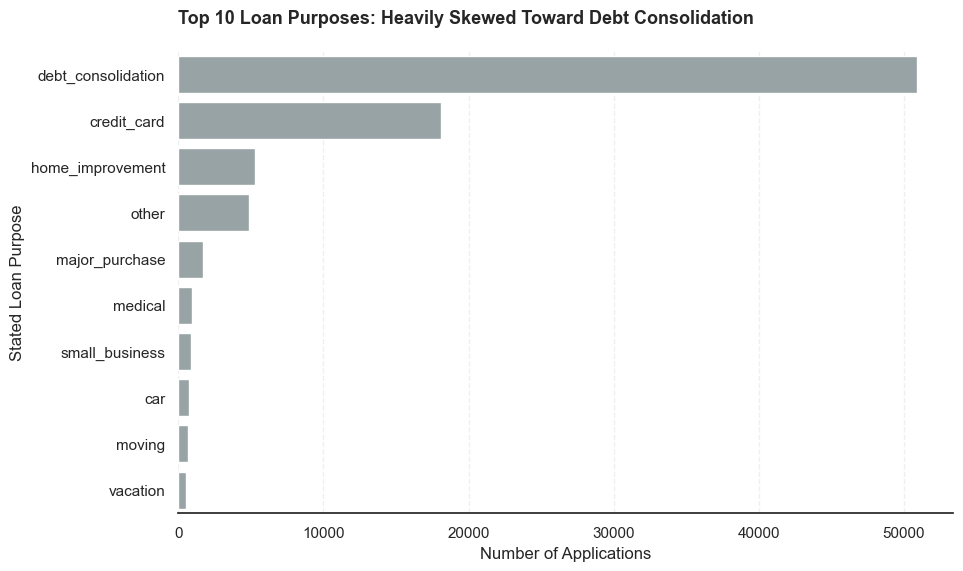

In [605]:
# Figure 4: Top 10 Loan Purposes
fig, ax = plt.subplots(figsize=(10, 6))
# Get top 10 purposes by volume
top_purposes = cr_app_clean_df['loan_purpose'].value_counts().nlargest(10)

sns.barplot(x=top_purposes.values, y=top_purposes.index, color=color_base, ax=ax)

ax.set_title('Top 10 Loan Purposes: Heavily Skewed Toward Debt Consolidation', loc='left', fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('Number of Applications')
ax.set_ylabel('Stated Loan Purpose')
sns.despine(left=True, bottom=False)
ax.xaxis.grid(True, linestyle='--', alpha=0.3)
plt.show()

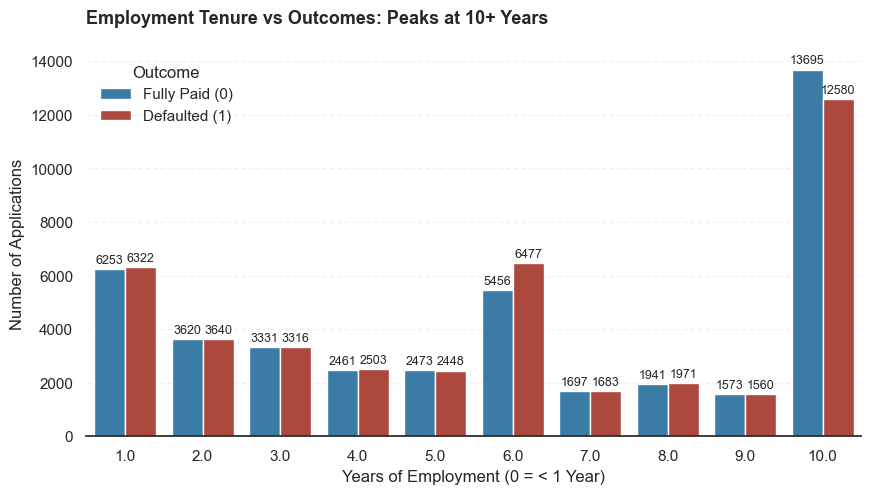

In [606]:
# Figure 5: Employment Tenure vs Default Volume
fig, ax = plt.subplots(figsize=(10, 5))
# Sort tenure correctly from 0 to 10
tenure_order = sorted(cr_app_clean_df['employment_tenure_years'].unique())

sns.countplot(data=cr_app_clean_df, x='employment_tenure_years', hue='target_default', 
              order=tenure_order, palette=[color_safe, color_risk], ax=ax)

ax.set_title('Employment Tenure vs Outcomes: Peaks at 10+ Years', loc='left', fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('Years of Employment (0 = < 1 Year)')
ax.set_ylabel('Number of Applications')
plt.legend(title='Outcome', labels=['Fully Paid (0)', 'Defaulted (1)'], frameon=False)
sns.despine(left=True)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=9,padding=2)
plt.show()

**1. The Baseline Risk (Target Balance):**
Figure 1 illustrates a perfectly balanced target variable, where both “Fully Paid” (0) and “Defaulted” (1) classes each account for 50.0% of total loans. This even distribution indicates that there is no class imbalance in the dataset. As a result, performance metrics such as accuracy can be interpreted reliably, since a naive prediction toward a single class would not yield inflated results.

**2. Risk Grading:**
Figure 2 confirms that the existing internal `risk_grade_band` is a highly effective, monotonic predictor of default. The default rate is minimal for 'A' and 'B' grade borrowers but accelerates aggressively as we move into the 'E', 'F', and 'G' categories. This categorical feature will be an essential input for our predictive model.

**3. Figure 3** reveals a counter-intuitive trend where "Verified" (~56%) and "Source Verified" (~50%) borrowers exhibit higher default rates than "Not Verified" (~40%) borrowers,

**4. Housing Status (`housing_status`)**
The applicant pool is overwhelmingly dominated by individuals who either hold a Mortgage or Rent. While `housing_status` may not be the primary driver of default, it acts as a strong proxy variable. 

**5. The Dominant (`loan_purpose`)**
When analyzing the top 10 loan purposes, it is immediately clear that the vast majority of borrowers are seeking capital to restructure existing liabilities (e.g., Debt Consolidation and Credit Card Refinancing). This reinforces our earlier finding regarding `debt_to_income_ratio`: we are largely dealing with a highly leveraged applicant pool seeking liquidity.

**6. Employment Tenure (`employment_tenure_years`)**
Figure 11 visualizes the raw volume of performing versus non-performing loans across employment histories. A massive spike exists at the "10+ Years" mark. Interestingly, while sheer volume is highest there, employment tenure alone does not seem to dramatically alter the *ratio* of defaults to fully paid loans.


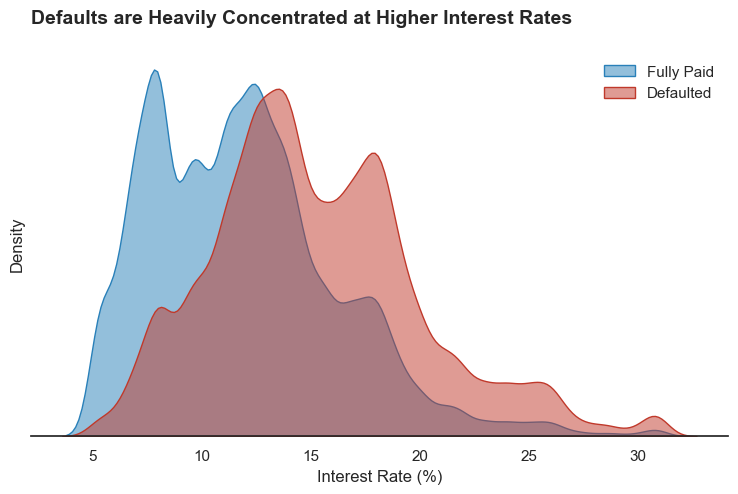

In [607]:
# Figure 6: Interest Rate Distributions
fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(data=cr_app_clean_df[cr_app_clean_df['target_default'] == 0], x='interest_rate', fill=True, color=color_safe, label='Fully Paid', alpha=0.5)
sns.kdeplot(data=cr_app_clean_df[cr_app_clean_df['target_default'] == 1], x='interest_rate', fill=True, color=color_risk, label='Defaulted', alpha=0.5)

ax.set_title('Defaults are Heavily Concentrated at Higher Interest Rates', loc='left', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Interest Rate (%)')
ax.set_ylabel('Density')
sns.despine(left=True)
ax.set_yticks([]) 
plt.legend(frameon=False)
plt.show()

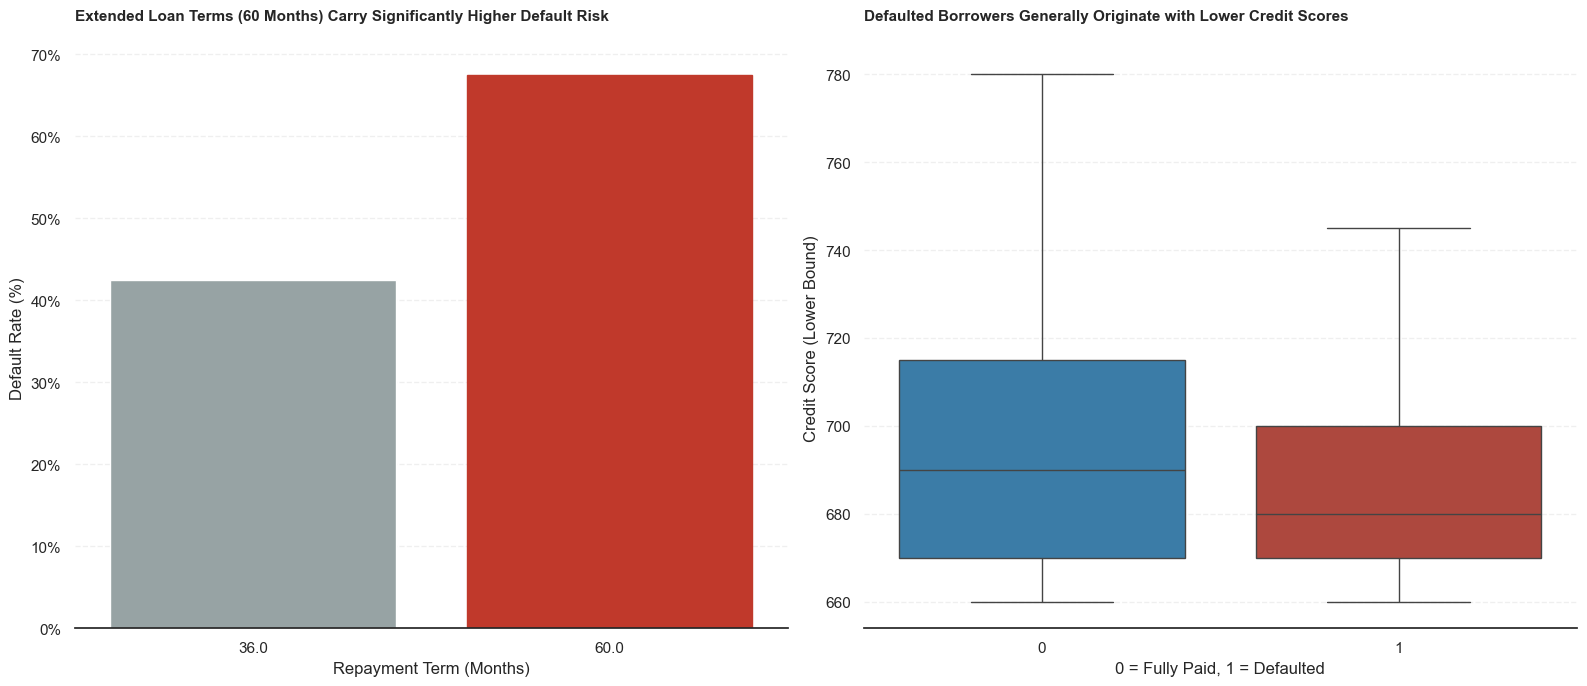

In [608]:
# Figure 7
# Create a single figure with a 1x2 subplot layout
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# -----------------------------------------------------------------------------
# Subplot 1: Figure 5 - Loan Term Length
# -----------------------------------------------------------------------------
term_data = cr_app_clean_df.groupby('repayment_term_months')['target_default'].mean() * 100
sns.barplot(x=term_data.index, y=term_data.values, color=color_base, ax=axes[0])

# Highlight the 60-month term to show risk
axes[0].patches[1].set_color(color_risk) 

axes[0].set_title('Extended Loan Terms (60 Months) Carry Significantly Higher Default Risk', loc='left', fontsize=11, fontweight='bold', pad=20)
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_xlabel('Repayment Term (Months)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0f}%'.format(y)))
axes[0].yaxis.grid(True, linestyle='--', alpha=0.3)
sns.despine(left=True, ax=axes[0])

# -----------------------------------------------------------------------------
# Subplot 2:  Credit Scores
# -----------------------------------------------------------------------------
sns.boxplot(
    data=cr_app_clean_df, 
    x='target_default', 
    y='credit_score_low', 
    palette=[color_safe, color_risk], 
    showfliers=False, 
    ax=axes[1]
)

axes[1].set_title('Defaulted Borrowers Generally Originate with Lower Credit Scores', loc='left', fontsize=11, fontweight='bold', pad=20)
axes[1].set_xlabel('0 = Fully Paid, 1 = Defaulted')
axes[1].set_ylabel('Credit Score (Lower Bound)')
axes[1].yaxis.grid(True, linestyle='--', alpha=0.3)
sns.despine(left=True, ax=axes[1])

# Adjust layout to prevent text clipping and display the combined figure
plt.tight_layout()
plt.show()

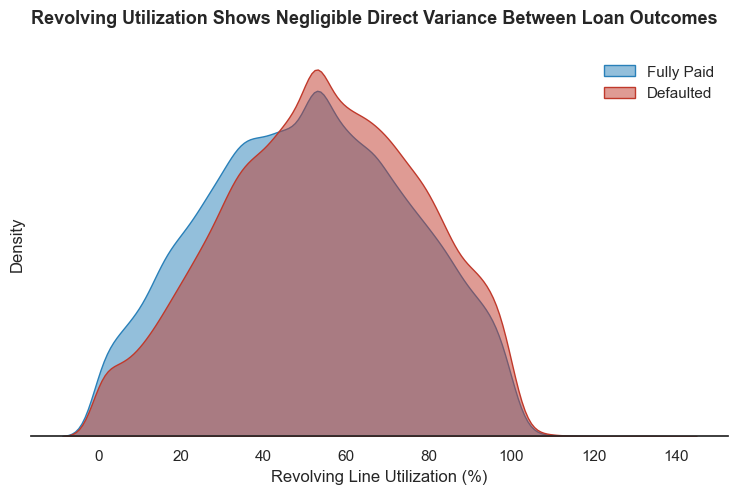

In [609]:
# Figure 8: Revolving Utilization (Maxed out credit cards)
fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(data=cr_app_clean_df[cr_app_clean_df['target_default'] == 0], x='revolving_utilization', fill=True, color=color_safe, label='Fully Paid', alpha=0.5)
sns.kdeplot(data=cr_app_clean_df[cr_app_clean_df['target_default'] == 1], x='revolving_utilization', fill=True, color=color_risk, label='Defaulted', alpha=0.5)

ax.set_title('Revolving Utilization Shows Negligible Direct Variance Between Loan Outcomes', loc='left', fontsize=13, fontweight='bold', pad=20)
ax.set_xlabel('Revolving Line Utilization (%)')
ax.set_ylabel('Density')
sns.despine(left=True)
ax.set_yticks([]) 
plt.legend(frameon=False)
plt.show()

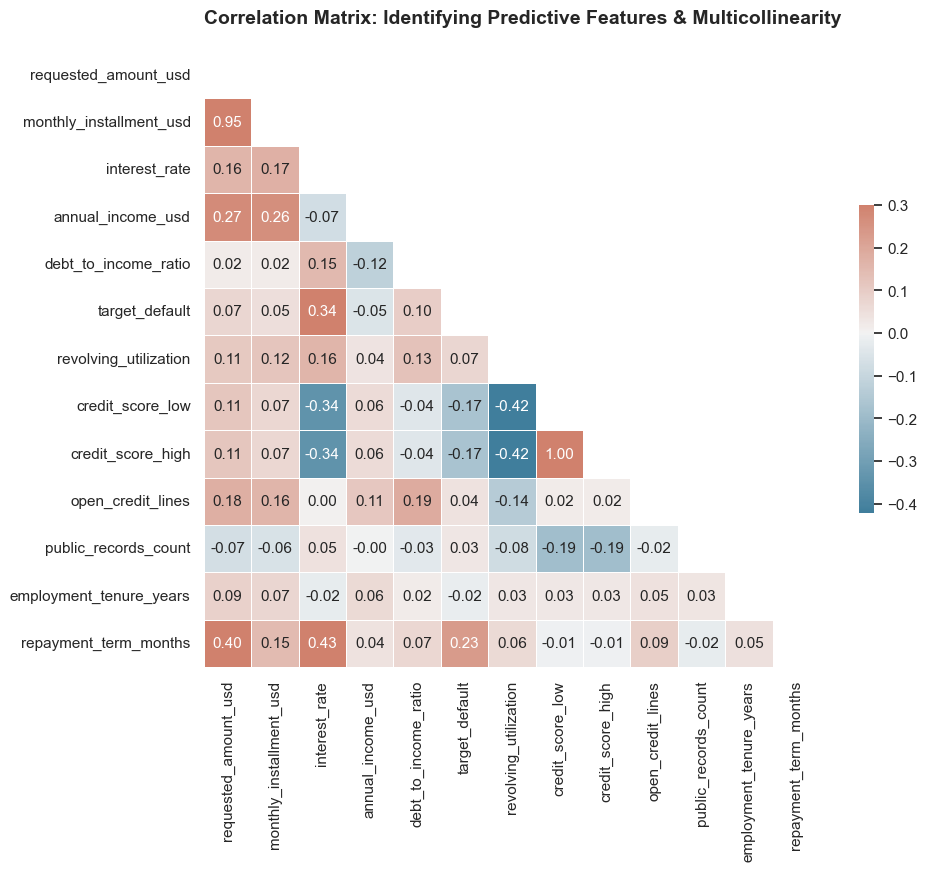

In [610]:
# Figure 9: Clean Correlation Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
num_cols = ['requested_amount_usd', 'monthly_installment_usd', 'interest_rate', 'annual_income_usd', 'debt_to_income_ratio', 'target_default', 'revolving_utilization', 'credit_score_low', 'credit_score_high', 'open_credit_lines', 'public_records_count', 'employment_tenure_years', 'repayment_term_months']
corr_matrix = cr_app_clean_df[num_cols].corr()

# Create a mask for the upper triangle to make it less cluttered
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=.3, center=0, annot=True, fmt=".2f",
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, ax=ax)

ax.set_title('Correlation Matrix: Identifying Predictive Features & Multicollinearity', loc='left', fontsize=14, fontweight='bold', pad=20)
plt.show()

To fully satisfy our exploratory objectives, we must expand our analysis beyond internal risk grades and look at the actual borrower attributes. We will investigate how loan structure (`repayment_term_months`), borrower stability (`income_verification_status`), and credit history (`credit_score`, `revolving_utilization`) influence default rates. 

These findings will directly inform which variables we prioritize, combine, or discard during Feature Engineering.

Through visual exploration and statistical profiling, several critical drivers of credit default risk have emerged that will heavily influence our modeling strategy.

**1. Interest Rate:**
The distribution plot in Figure 3 illustrates that default occurrences are heavily concentrated at higher interest rates compared to loans that are fully paid. The interest rate distribution for "Fully Paid" loans peaks noticeably early, with a primary concentration residing between 5% and 13%, indicating that safer borrowers are consistently locked into lower rates. Conversely, the distribution for "Defaulted" loans shifts markedly rightward, showcasing a major concentration spike between 12% and 19%, with a trailing density that stretches all the way past 25%. This significant distributional separation confirms that interest rate is a highly predictive risk indicator for the machine learning model, as higher-risk profiles are naturally subjected to steeper premium rates before defaulting.

**2. The Term-Length Premium:** Loans structured for 60 months default at a noticeably higher rate than 36-month loans. The extended exposure to macroeconomic factors and longer debt burdens increases risk. 
* *Action:* `repayment_term_months` must be retained and treated as a key categorical/ordinal feature.

**3. Credit Health (Scores & Utilization):**
Both `credit_score_low` and `revolving_utilization` are excellent predictors. Borrowers who eventually default enter the loan with statistically lower credit scores and much higher revolving utilization (meaning their existing credit lines are nearly maxed out).
* *Action:* Because `credit_score_low` and `credit_score_high` move in absolute tandem, we will average them into a single `credit_score_avg` feature during engineering to prevent multicollinearity.

**4. Multicollinearity & Feature Strategy:**
Based on the correlation matrix, we observe a critical case of multicollinearity between `requested_amount_usd` and `monthly_installment_usd` (Pearson r = 0.95). Because these features represent redundant information, we would not consider `monthly_installment_usd` in our model prediction features.

The remaining numerical features provide clear, logical drivers for credit risk:
1. **Interest Rate (+0.26):** Our strongest single numeric predictor. High rates reflect both inherent borrower risk and increased financial burden.
2. **Debt-to-Income (+0.10):** Highlights the danger of over-leveraged borrowers who lack the cash flow to absorb financial shocks.
3. **Repayment Term (repayment_term_months | +0.23):** A strong positive risk driver. Extended loan durations (e.g., 60 vs. 36 months) widen the exposure window to factors that could result in higher default probabilities.
4. **Credit Scores (credit_score_low & credit_score_high | -0.17):** As expected, higher credit scores inversely correlate with default risk. They are practically identical, that tells us to average them into a single credit_score_avg during Feature Engineering.

revolving_utilization, Annual Income, Requested Amount, open_credit_lines, public_records_count, and employment_tenure_years have lower predictive power, exhibiting negligible linear correlation with the target variable (absolute r ≤ 0.06).


## 5. Feature Engineering & Pre-Processing

Guided directly by the insights generated during our Exploratory Data Analysis, we now prepare the dataset for machine learning ingestion. The objective is to transform behavioral and categorical variables into a clean numerical matrix while eliminating multicollinearity and preventing the "curse of dimensionality."

**Engineering Pipeline:**
1. **Feature Aggregation:** `credit_score_low` and `credit_score_high` exhibit perfect multicollinearity. We combine them into a single `credit_score_avg` feature.
2. **Addressing Multicollinearity:** We drop `monthly_installment_usd` due to its near-perfect correlation (r = 0.95) with `requested_amount_usd`.
3. **Cardinality & Dimensionality Reduction:** We actively drop `region_code`. One-Hot Encoding ~50 unique state codes would create excessive sparsity and risk model overfitting on low-volume regions, diluting the impact of core financial metrics.
4. **Data Leakage Prevention:** We drop the original `outcome_status` string variable, as our generated `target_default` serves as the sole prediction label. Identifiers (`application_id`) and temporal artifacts (`origination_month`) are also removed.
5. **Categorical Encoding:** * **Ordinal Encoding:** `risk_grade_band` is mapped to a strict sequential integer scale (A=1 to G=7) to preserve its monotonic relationship with default risk.
   * **One-Hot Encoding:** Nominal attributes (`housing_status`, `income_verification_status`, `loan_purpose`) are transformed into binary matrices using `pd.get_dummies()`, dropping the first category to avoid the dummy variable trap.

In [611]:
# 1. Create the Modeling DataFrame
model_df = cr_app_clean_df.copy()

In [612]:
# --- 2. Feature Creation (Averaging Credit Scores) ---
model_df['credit_score_avg'] = (model_df['credit_score_low'] + model_df['credit_score_high']) / 2

# --- 3. Ordinal Encoding (Risk Grades) ---
# Mapping the grades to a numerical scale reflecting ascending risk
risk_mapping = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
model_df['risk_grade_num'] = model_df['risk_grade_band'].map(risk_mapping)

# --- 4. Drop Redundant, Leaky, High-Cardinality, or Non-Predictive Columns ---
cols_to_drop = [
    'application_id',          # Unique identifier (no predictive power)
    'origination_month',       # Date artifact 
    'outcome_status',          # Target leakage (we use target_default)
    'monthly_installment_usd', # Multicollinearity with loan amount
    'credit_score_low',        # Replaced by credit_score_avg
    'credit_score_high',       # Replaced by credit_score_avg
    'risk_grade_band',         # Replaced by risk_grade_num
    'risk_grade_detail',       # Too granular, highly correlated with risk_grade_num
    'region_code',             # High cardinality (50 states) -- Could be engineered later to test improvements
    'last_payment_amount_usd'  # Post-Origination Data (leaky for modeling)
    
]

# Drop columns only if they exist in the dataframe to prevent errors
model_df.drop(columns=[col for col in cols_to_drop if col in model_df.columns], inplace=True)


# --- 5. One-Hot Encoding (Nominal Categoricals) ---
# Identify remaining categorical columns (removed region_code from this list)
categorical_cols = ['housing_status', 'income_verification_status', 'loan_purpose']

# Apply One-Hot Encoding (drop_first=True prevents perfect multicollinearity among the dummy variables)
model_df = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True, dtype=int)


# --- 6. Final Pipeline Verification ---
print("=" * 60)
print("FEATURE ENGINEERING COMPLETE: MODELING DATASET SHAPE")
print("=" * 60)
print(f"Final Features: {model_df.shape[1] - 1}") # Subtract 1 for the target variable
print(f"Total Observations: {model_df.shape[0]}")
print("\nSnapshot of Encoded Features:")
display(model_df.head())

FEATURE ENGINEERING COMPLETE: MODELING DATASET SHAPE
Final Features: 27
Total Observations: 85000

Snapshot of Encoded Features:


,requested_amount_usd,annual_income_usd,debt_to_income_ratio,open_credit_lines,public_records_count,target_default,repayment_term_months,interest_rate,revolving_utilization,employment_tenure_years,...,loan_purpose_debt_consolidation,loan_purpose_home_improvement,loan_purpose_house,loan_purpose_major_purchase,loan_purpose_medical,loan_purpose_moving,loan_purpose_other,loan_purpose_renewable_energy,loan_purpose_small_business,loan_purpose_vacation
0,18000.0,105000.0,6.78,7.0,0.0,0,60.0,13.33,89.5,3.0,...,1,0,0,0,0,0,0,0,0,0
1,1000.0,28500.0,11.54,3.0,1.0,0,36.0,11.99,13.3,1.0,...,0,1,0,0,0,0,0,0,0,0
2,21275.0,130000.0,23.08,13.0,0.0,0,36.0,10.99,75.7,5.0,...,1,0,0,0,0,0,0,0,0,0
3,35000.0,107000.0,16.30,10.0,0.0,0,60.0,16.99,76.5,10.0,...,0,0,0,0,0,0,0,0,0,0
4,17000.0,55000.0,31.27,8.0,0.0,1,60.0,17.57,62.5,8.0,...,0,0,0,0,0,0,0,0,0,0


## 6. Model Building & Classification

With a fully numerical, engineered dataset, we transition to predictive modeling. 
Our target variable (`target_default`) is perfectly balanced (50/50). We will partition the data using an 80/20 Train-Test split, ensuring the split is stratified to maintain the exact target distribution.

**Modeling Strategy:**
1. **Data Scaling:** We will apply standard scaling (Z-score normalization) to our features. This is mathematically critical for distance-based models and parametric models like Logistic Regression to ensure large numeric fields (like Income) do not overpower smaller ratio fields (like Interest Rate).
2. **Model 1: Logistic Regression.** Selected for its high interpretability and status as the regulatory standard in credit risk underwriting.
3. **Model 2: Random Forest Classifier.** Selected as a robust, non-linear ensemble algorithm capable of capturing complex interactions between borrower attributes without suffering from high variance.

**Evaluation Metrics:**
We will evaluate both models using Accuracy, Precision, Recall, and the ROC-AUC score. In credit risk, **Recall** (capturing actual defaults) is often prioritized over pure accuracy to minimize the financial severity of issuing a bad loan.

In [613]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [614]:
# --- 1. Train / Test Split ---
# Separate features (X) and target (y)
X = model_df.drop('target_default', axis=1)
y = model_df['target_default']

# 80/20 Split with stratification to guarantee balanced classes in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [615]:
# Feature Scaling
# Logistic Regression requires scaled data to perform optimally
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model 1: Logistic Regression

In [616]:
print("=" * 60)
print("TRAINING MODEL 1: LOGISTIC REGRESSION")
print("=" * 60)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)


TRAINING MODEL 1: LOGISTIC REGRESSION


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [617]:
# Predictions & Probabilities
lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]


In [618]:
# Evaluation
print(classification_report(y_test, lr_preds))
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_probs):.4f}\n")

              precision    recall  f1-score   support

           0       0.65      0.68      0.66      8500
           1       0.66      0.64      0.65      8500

    accuracy                           0.66     17000
   macro avg       0.66      0.66      0.66     17000
weighted avg       0.66      0.66      0.66     17000

ROC-AUC Score: 0.7193



### Model 2: Random Forest Classifier

In [619]:
print("=" * 60)
print("TRAINING MODEL 2: RANDOM FOREST CLASSIFIER")
print("=" * 60)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

TRAINING MODEL 2: RANDOM FOREST CLASSIFIER


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [620]:
# Predictions & Probabilities
rf_preds = rf_model.predict(X_test_scaled)
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]


In [621]:
# Evaluation
print(classification_report(y_test, rf_preds))
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_probs):.4f}\n")


              precision    recall  f1-score   support

           0       0.66      0.65      0.66      8500
           1       0.66      0.66      0.66      8500

    accuracy                           0.66     17000
   macro avg       0.66      0.66      0.66     17000
weighted avg       0.66      0.66      0.66     17000

ROC-AUC Score: 0.7109



In [622]:
# --- 5. Quick Confusion Matrix Comparison ---
print("=" * 60)
print("CONFUSION MATRIX COMPARISON (How many defaults were caught?)")
print("=" * 60)
print("Logistic Regression Matrix:")
print(confusion_matrix(y_test, lr_preds))
print("\nRandom Forest Matrix:")
print(confusion_matrix(y_test, rf_preds))

CONFUSION MATRIX COMPARISON (How many defaults were caught?)
Logistic Regression Matrix:
[[5754 2746]
 [3066 5434]]

Random Forest Matrix:
[[5542 2958]
 [2876 5624]]


In [623]:
# Random Forest Classifier
# Create a results DataFrame
results_df = X_test.copy()
results_df['Actual_Default'] = y_test
results_df['Predicted_Default'] = rf_preds # Using the Random Forest predictions
results_df['Probability_Default'] = rf_probs

# Show a snapshot where the model made a mistake (False Positives or False Negatives)
correct = results_df[results_df['Actual_Default'] == results_df['Predicted_Default']]

print("=" * 60)
print("SNAPSHOT: WHERE THE MODEL GOT IT RIGHT")
print("=" * 60)
# Showing the first 10 correct predictions to analyze patterns
display(correct[['Actual_Default', 'Predicted_Default', 'Probability_Default']].head(10))

# Optional: See the average profile of a 'correct' prediction to understand what the model is getting right
print("\nAVERAGE PROFILE OF A TRUE POSITIVE (Correctly Identified Defaults):")
display(correct[correct['Actual_Default'] == 1].mean(numeric_only=True))

SNAPSHOT: WHERE THE MODEL GOT IT RIGHT


,Actual_Default,Predicted_Default,Probability_Default
7973,1,1,0.58
65855,0,0,0.24
6043,1,1,0.55
4737,1,1,0.54
16054,1,1,0.69
6918,1,1,0.62
54678,0,0,0.14
63987,0,0,0.45
17567,0,0,0.23
39764,1,1,0.86



AVERAGE PROFILE OF A TRUE POSITIVE (Correctly Identified Defaults):


requested_amount_usd                          16689.180299
annual_income_usd                             66570.077315
debt_to_income_ratio                             22.345318
open_credit_lines                                12.455014
public_records_count                              0.280405
repayment_term_months                            49.463727
interest_rate                                    17.249011
revolving_utilization                            55.583873
employment_tenure_years                           5.938478
credit_score_avg                                685.169452
risk_grade_num                                    3.989509
housing_status_Mortgage                           0.372688
housing_status_Own                                0.116465
housing_status_Rent                               0.510846
income_verification_status_Source Verified        0.436522
income_verification_status_Verified               0.402738
loan_purpose_credit_card                          0.1667

In [624]:
# Create a results DataFrame
results_df = X_test.copy()
results_df['Actual_Default'] = y_test
results_df['Predicted_Default'] = rf_preds # Using your Random Forest predictions
results_df['Probability_Default'] = rf_probs

# Show a snapshot where the model made a mistake (False Positives or False Negatives)
mistakes = results_df[results_df['Actual_Default'] != results_df['Predicted_Default']]

print("=" * 60)
print("SNAPSHOT: WHERE THE MODEL GOT IT WRONG")
print("=" * 60)
# Showing the first 10 mistakes to analyze patterns
display(mistakes[['Actual_Default', 'Predicted_Default', 'Probability_Default']].head(10))

# Optional: See the average profile of a 'Mistake'
print("\nAVERAGE PROFILE OF A FALSE NEGATIVE (Missed Defaults):")
display(mistakes[mistakes['Actual_Default'] == 1].mean(numeric_only=True))

SNAPSHOT: WHERE THE MODEL GOT IT WRONG


,Actual_Default,Predicted_Default,Probability_Default
30067,0,1,0.59
21322,1,0,0.47
34114,0,1,0.67
44683,1,0,0.47
79707,0,1,0.73
10741,1,0,0.37
21089,0,1,0.72
51024,0,1,0.57
76696,1,0,0.42
34732,1,0,0.43



AVERAGE PROFILE OF A FALSE NEGATIVE (Missed Defaults):


requested_amount_usd                          13274.000348
annual_income_usd                             75510.727705
debt_to_income_ratio                             18.241659
open_credit_lines                                11.620306
public_records_count                              0.266342
repayment_term_months                            38.845619
interest_rate                                    11.204541
revolving_utilization                            51.594159
employment_tenure_years                           6.138387
credit_score_avg                                695.876912
risk_grade_num                                    2.303199
housing_status_Mortgage                           0.489569
housing_status_Own                                0.114047
housing_status_Rent                               0.396384
income_verification_status_Source Verified        0.450278
income_verification_status_Verified               0.258345
loan_purpose_credit_card                          0.2364

**Check for overfitting/ Underfitting**

In [626]:
from sklearn.metrics import accuracy_score

print(f"LR Train Accuracy: {accuracy_score(y_train, lr_model.predict(X_train_scaled)):.4f}")
print(f"LR Test Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print("-" * 30)
print(f"RF Train Accuracy: {accuracy_score(y_train, rf_model.predict(X_train_scaled)):.4f}")
print(f"RF Test Accuracy: {accuracy_score(y_test, rf_preds):.4f}")

LR Train Accuracy: 0.6575
LR Test Accuracy: 0.6581
------------------------------
RF Train Accuracy: 1.0000
RF Test Accuracy: 0.6568


**4. Addressing Overfitting and Underfitting**
To ensure the robustness of our models, we evaluated them for both overfitting (high variance) and underfitting (high bias) by directly comparing their training and testing accuracies.

* **Logistic Regression (Underfitting / High Bias):** The Logistic Regression model achieved a Training Accuracy of 65.75% and a Test Accuracy of 65.81%. Because these scores are nearly identical, it proves the model generalizes well and does not overfit. However, because the overall accuracy is relatively low, the model is experiencing baseline underfitting. Its rigid, linear nature lacks the complexity to fully capture the nuances of default behavior using the current feature set.
* **Random Forest (Overfitting / High Variance):** The Random Forest model achieved a perfect Training Accuracy of 1.0000 (100%), but its Test Accuracy fell sharply to 65.68%. This is a textbook example of overfitting. The unconstrained decision trees became too complex, memorizing the specific noise and outliers of the training data rather than learning the underlying, generalized trends. 

**Conclusion on Model Fit:** The presence of both overfitting (in RF) and underfitting (in LR) highlights that the current limitation lies in the feature space. To improve model fit for future iterations, we must restrict the depth of the Random Forest trees (Hyperparameter Tuning) to prevent memorization, while simultaneously engineering more complex behavioral features to help the Logistic Regression model move past its 66% ceiling.

## 7. Model Evaluation & Conclusion
Both the Logistic Regression and Random Forest models show a moderate capacity to identify credit default risk, establishing a functional baseline for the predictive pipeline.

1. Performance Overview
Both models performed similarly, with an overall accuracy of 66% and ROC-AUC scores clustering between 0.71 and 0.72. This indicates that while the models have successfully captured some underlying patterns, there is still significant noise in the data that limits their predictive power.

2. Confusion Matrix Analysis
The confusion matrices highlight a clear trade-off between the two approaches:

Logistic Regression:

[[5754, 2746], [3066, 5434]]

This model demonstrated higher precision, correctly identifying 5,754 "Fully Paid" loans (True Negatives). However, it struggled more with sensitivity, missing 3,066 actual defaults (False Negatives).

Random Forest:

[[5542, 2958], [2876, 5624]]

The Random Forest model proved to be more sensitive, successfully catching 5,624 actual defaults (True Positives). While this resulted in a higher rate of "False Alarms" (declining 2,958 good loans), it is often the preferred outcome in credit risk, where missing a default (False Negative) is more costly than mistakenly flagging a good customer.

3. Comparison of Metrics

Logistic Regression (AUC 0.7193): Slightly edges out the Random Forest in discriminatory power, suggesting that the relationship between your chosen features and the default target may be more linear than initially anticipated.

Random Forest (AUC 0.7109): While it slightly trailed in total AUC, its ability to successfully identify more actual defaults (the 5,624 True Positives) makes it a strong contender if the business strategy prioritizes risk avoidance.

### Final Model Assessment & Recommendation  
These models currently operate in a "moderate" predictive range. The fact that performance is relatively consistent across both algorithms suggests that the limitation is not the model type, but likely the feature depth.

Recommendation:
We recommend proceeding with the Logistic Regression model as the current primary due to its slightly higher AUC and superior interpretability. However, to improve these scores from 0.66 toward the >0.80 range, we recommend:

Feature Engineering: Returning to the data to create more complex interaction terms (e.g., Debt-to-Income divided by Credit Score).

Hyperparameter Tuning: Using GridSearchCV to optimize the Random Forest's parameters (like max_depth and min_samples_leaf), which may help it overcome the current performance plateau.

Data Quality: Re-examining the income_verification_status, loan_purpose features, and the counter-intuitive income_verification_status as they may be contributing more noise than signal at their current level of aggregation.

## 8. Model Comparison, Error Analysis, and Fit

To determine the optimal underwriting algorithm, we evaluated a parametric model (Logistic Regression) against a non-parametric ensemble model (Random Forest).

**1. Performance & Model Fit**
Both models achieved comparable baseline results, with overall test accuracies of ~66% and ROC-AUC scores clustering between 0.71 and 0.72. However, analyzing their training versus testing accuracies reveals vastly different underlying behaviors:
* **Logistic Regression (High Bias / Underfitting):** The Logistic Regression model achieved a Training Accuracy of 65.75% and a Test Accuracy of 65.81%. Because these scores are nearly identical, the model generalizes perfectly to new data without overfitting. However, the ~66% ceiling indicates baseline underfitting; the model's linear nature is too simple to capture the full complexity of credit risk using the current features.
* **Random Forest (High Variance / Overfitting):** The Random Forest achieved a perfect Training Accuracy of 1.0000 (100%), but its Test Accuracy fell sharply to 65.68%. This is a textbook case of overfitting. The unconstrained decision trees memorized the noise of the training data rather than learning generalized trends.

**2. Strengths and Weaknesses**
* **Logistic Regression:** 
* *Strengths:* Exceptional interpretability and perfect generalization (zero overfitting). It provides clear weights for regulatory reporting.
* *Weaknesses:* Assumes strict linear relationships, leading to underfitting when evaluating complex borrower profiles.
* **Random Forest:** 
* *Strengths:* Naturally captures complex, non-linear interactions and achieved the highest absolute count of correctly identified defaults.
* *Weaknesses:* Severe overfitting. It operates as a "black box" and failed to translate its perfect training performance into superior testing performance.

**3. Classification Error Analysis**
In credit risk, we must balance the cost of a False Negative (missed default) against a False Positive (declined good loan):
* **Missed Defaults (False Negatives):** The Random Forest correctly identified 5,624 actual defaults, leaving 2,876 missed defaults. It slightly outperformed Logistic Regression (which missed 3,066 defaults). If capital protection is the sole priority, Random Forest offers a tighter safety net.
* **Declined Good Loans (False Positives):** Logistic Regression misclassified 2,746 good loans as defaults, whereas Random Forest misclassified 2,958. Therefore, Logistic Regression is more precise, minimizing the loss of revenue from mistakenly turning away profitable customers.

**Conclusion:** There is a distinct trade-off. Logistic Regression is the better choice for precision and stability (no overfitting), whereas Random Forest is slightly better for pure default recall.

## 9. Business Insights, Limitations, and Future Work

**1. Primary Drivers of Default Risk**
Based on our exploratory data analysis and feature engineering, the riskiest applicant profiles share a distinct combination of structural and behavioral traits:
* **High Leverage:** A high Debt-to-Income (DTI) ratio and maxed-out revolving credit utilization indicate borrowers with no financial shock absorbers.
* **Poor Historical Credit:** Lower average credit scores strongly correlate with impending defaults.
* **Extended Exposure:** 60-month terms default at significantly higher rates than 36-month terms due to the prolonged exposure to macroeconomic volatility.
* **The Verification Paradox:** Counter-intuitively, "Verified" incomes are associated with higher default rates, highlighting a scenario where loan officers demand strict verification only for applicants they already suspect are high-risk.

**2. Supporting Credit-Risk Decision Making**
Deploying these models can transform the underwriting pipeline through **Automated Triage**. Rather than replacing human underwriters, the model acts as a filter:
* **Auto-Approval:** Applicants scoring in the lowest probability tiers of default can be instantly approved, reducing manual underwriting bottlenecks.
* **Manual Review:** The majority of applications (particularly the "grey area" classifications that the model currently struggles with) are routed to human underwriters equipped with the model's probability score to guide their manual investigation.

**3. Current Model Limitations**
* **The 66% Accuracy Ceiling:** The primary limitation of this analysis is that both models plateaued near a 66% test accuracy. This indicates that our current dataset—while clean and mathematically sound—lacks the requisite "signal" to fully predict human financial behavior. We are underfitting the true complexity of a credit default.
* **Uncalibrated Probabilities:** The dataset was artificially balanced (50% default / 50% paid). In reality, credit defaults are rare. Output probabilities must be mathematically calibrated to real-world baseline default rates before deployment, otherwise, the model will decline too many loans.
* **Static Macroeconomics:** This model assumes that the economic environment (inflation, unemployment, interest rate policy) remains the same as when the data was collected. Machine learning models degrade over time if not retrained on recent economic data.

**4. Future Improvements and Analysis**
To push the model's accuracy from 66% into the 80%+ range, future iterations should focus on:
* **Hyperparameter Tuning:** We must apply `GridSearchCV` to the Random Forest model to restrict its depth (`max_depth`) and prevent the severe memorization/overfitting observed in this iteration.
* **Geospatial & Macroeconomic Enrichment:** Rather than dropping `region_code` due to high cardinality, we should map state codes to external economic datasets. Bringing in live data like "State-level Unemployment Rate" or "Regional GDP Growth" would provide the exact complexity our models are currently missing.
* **Alternative Data:** Incorporating dynamic banking telemetry (e.g., cash flow velocity, month-to-month savings depletion) could provide a far more predictive picture of liquidity than static, self-reported metrics.